In [1]:
"""
Module 05: Sentiment & Marketing Attribution — NYC→Dubai Route
================================================================
Data Sources: Google Places API — Dubai (#1) + YouTube Data API v3 (#5)

Business Questions:
  1. What do travelers actually SAY about Dubai hotels?
  2. Which YouTube content themes drive the most engagement?
  3. How does sentiment correlate with hotel star ratings?
  4. What content gaps should the OTA fill?
"""
import sys, os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 4))
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

from config.settings import YOUTUBE_SEARCH_QUERIES
from src.data_collection.google_places import generate_synthetic_hotels
from src.data_collection.youtube_collector import generate_synthetic_youtube_data
from src.analysis.funnel_analyzer import prepare_funnel_data
from src.analysis.sentiment_engine import (
    extract_reviews, analyze_review_sentiment, extract_sentiment_topics,
    aggregate_sentiment_by_group, sentiment_rating_correlation,
    prepare_youtube_data, analyze_theme_performance,
    analyze_publish_timing, analyze_channel_performance,
    identify_content_gaps, generate_marketing_recommendations,
    run_full_sentiment_analysis,
)

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)

print("✅ Imports loaded")

✅ Imports loaded


In [3]:
from config.settings import GOOGLE_CLOUD_API_KEY
from src.data_collection.google_places import (
    fetch_both_markets, generate_synthetic_hotels,
)
from src.data_collection.youtube_collector import (
    fetch_youtube_data, generate_synthetic_youtube_data,
    HAS_YT_CLIENT,
)

# ── Hotel data ──
if GOOGLE_CLOUD_API_KEY:
    print(f"✅ Google API key found: {GOOGLE_CLOUD_API_KEY[:8]}...")
    hotels = fetch_both_markets(fetch_details=True)    # LIVE API
    if hotels.empty:
        print("⚠️ API returned no data — falling back to synthetic")
        hotels = generate_synthetic_hotels()
else:
    print("⚠️ No API key — using synthetic hotel data")
    hotels = generate_synthetic_hotels()

hotels = prepare_funnel_data(hotels)

# ── YouTube data ──
if GOOGLE_CLOUD_API_KEY and HAS_YT_CLIENT:
    print(f"✅ YouTube API available")
    youtube = fetch_youtube_data()                     # LIVE API
    if youtube.empty:
        print("⚠️ YouTube API returned no data — falling back to synthetic")
        youtube = generate_synthetic_youtube_data(n_videos=200)
else:
    reason = "no API key" if not GOOGLE_CLOUD_API_KEY else "google-api-python-client not installed"
    print(f"⚠️ {reason} — using synthetic YouTube data")
    youtube = generate_synthetic_youtube_data(n_videos=200)

print(f"\nHotels: {len(hotels)} ({hotels['MARKET'].value_counts().to_dict()})")
print(f"YouTube: {len(youtube)} videos, {youtube['VIEW_COUNT'].sum():,} total views")

✅ Google API key found: AIzaSyCN...

  Fetching Dubai Hotels
  Queries: 10 | Details: True

[1/10] 'luxury hotels Dubai'
    Page 1: +5 places (total: 5)

[2/10] 'budget hotels Dubai'
    Page 1: +9 places (total: 9)

[3/10] 'hotels Dubai Marina'
    Page 1: +8 places (total: 8)

[4/10] 'hotels Downtown Dubai'
    Page 1: +6 places (total: 6)

[5/10] 'hotels Palm Jumeirah'
    Page 1: +20 places (total: 20)

[6/10] 'hotels Deira Dubai'
    Page 1: +20 places (total: 20)
    API error (INVALID_REQUEST): 

[7/10] 'hotels JBR Dubai'
    Page 1: +12 places (total: 12)

[8/10] 'business hotels Dubai'
    Page 1: +10 places (total: 10)

[9/10] 'resorts Dubai'
    Page 1: +20 places (total: 20)
    API error (INVALID_REQUEST): 

[10/10] 'hotels Dubai Creek'
    Page 1: +18 places (total: 18)

📍 Unique hotels found: 111

📋 Fetching details for 111 hotels...
    Details fetched: 25/111
    Details fetched: 50/111
    Details fetched: 75/111
    Details fetched: 100/111
    ✅ Details complete fo

In [4]:
# ── Extract individual reviews ──
reviews = extract_reviews(hotels)
display(reviews.head())

# ── Run VADER sentiment analysis ──
reviews = analyze_review_sentiment(reviews)

# ── Extract topics ──
reviews = extract_sentiment_topics(reviews)
reviews.head(10)

Extracted 1,042 individual reviews from 210 hotels


,PLACE_ID,HOTEL_NAME,MARKET,NEIGHBORHOOD,PRICE_TIER,RATING,REVIEW_INDEX,REVIEW_TEXT
0,ChIJyTL-aggVXz4R4cAwRc0Ydsw,Atlantis The Royal,Dubai,,Unknown,4.7,0,One of the most beautiful resorts in the world...
1,ChIJyTL-aggVXz4R4cAwRc0Ydsw,Atlantis The Royal,Dubai,,Unknown,4.7,1,This hotel is breathtaking. Everything is beau...
2,ChIJyTL-aggVXz4R4cAwRc0Ydsw,Atlantis The Royal,Dubai,,Unknown,4.7,2,We honestly loved our stay at Atlantis The Roy...
3,ChIJyTL-aggVXz4R4cAwRc0Ydsw,Atlantis The Royal,Dubai,,Unknown,4.7,3,Our recent stay at Atlantis The Royal in Dubai...
4,ChIJyTL-aggVXz4R4cAwRc0Ydsw,Atlantis The Royal,Dubai,,Unknown,4.7,4,We cannot thank the Atlantis royal enough our ...



Sentiment analysis complete:
  Positive: 920 (88%)
  Neutral:  5 (0%)
  Negative: 117 (11%)

Topic extraction:
  {'location': np.int64(551), 'service': np.int64(401), 'room_quality': np.int64(48), 'price_value': np.int64(21), 'food_dining': np.int64(10), 'amenities': np.int64(8), 'general': np.int64(3)}


,PLACE_ID,HOTEL_NAME,MARKET,NEIGHBORHOOD,PRICE_TIER,RATING,REVIEW_INDEX,REVIEW_TEXT,VADER_COMPOUND,VADER_POS,...,VADER_NEG,SENTIMENT_LABEL,TOPIC_LOCATION,TOPIC_SERVICE,TOPIC_PRICE_VALUE,TOPIC_ROOM_QUALITY,TOPIC_FOOD_DINING,TOPIC_AMENITIES,TOPIC_VIEWS_AMBIANCE,PRIMARY_TOPIC
0,ChIJyTL-aggVXz4R4cAwRc0Ydsw,Atlantis The Royal,Dubai,,Unknown,4.7,0,One of the most beautiful resorts in the world...,0.9926,0.296,...,0.010,Positive,0,1,1,1,1,1,1,service
1,ChIJyTL-aggVXz4R4cAwRc0Ydsw,Atlantis The Royal,Dubai,,Unknown,4.7,1,This hotel is breathtaking. Everything is beau...,0.9955,0.374,...,0.022,Positive,0,1,0,1,1,1,1,service
2,ChIJyTL-aggVXz4R4cAwRc0Ydsw,Atlantis The Royal,Dubai,,Unknown,4.7,2,We honestly loved our stay at Atlantis The Roy...,0.9685,0.216,...,0.024,Positive,0,1,0,1,0,1,1,service
3,ChIJyTL-aggVXz4R4cAwRc0Ydsw,Atlantis The Royal,Dubai,,Unknown,4.7,3,Our recent stay at Atlantis The Royal in Dubai...,0.9935,0.274,...,0.000,Positive,0,1,0,1,1,1,1,service
4,ChIJyTL-aggVXz4R4cAwRc0Ydsw,Atlantis The Royal,Dubai,,Unknown,4.7,4,We cannot thank the Atlantis royal enough our ...,0.9963,0.273,...,0.012,Positive,0,1,0,1,1,1,1,service
5,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,,Unknown,4.7,0,Staying in a suite at the Burj Al Arab was tru...,0.9832,0.174,...,0.015,Positive,1,1,1,1,1,1,1,location
6,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,,Unknown,4.7,1,Burj al Arab is an iconic place for lots of ye...,0.9959,0.260,...,0.000,Positive,0,1,0,1,1,1,0,service
7,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,,Unknown,4.7,2,Our stay at the Burj Al Arab was honestly unfo...,0.9884,0.230,...,0.005,Positive,0,1,1,1,1,1,1,service
8,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,,Unknown,4.7,3,The view from the Skyview Bar is absolutely br...,0.9842,0.317,...,0.000,Positive,0,1,0,0,1,1,1,service
9,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,,Unknown,4.7,4,I went here for high tea for my husbands 50th ...,0.9643,0.226,...,0.000,Positive,0,0,0,0,1,0,0,food_dining


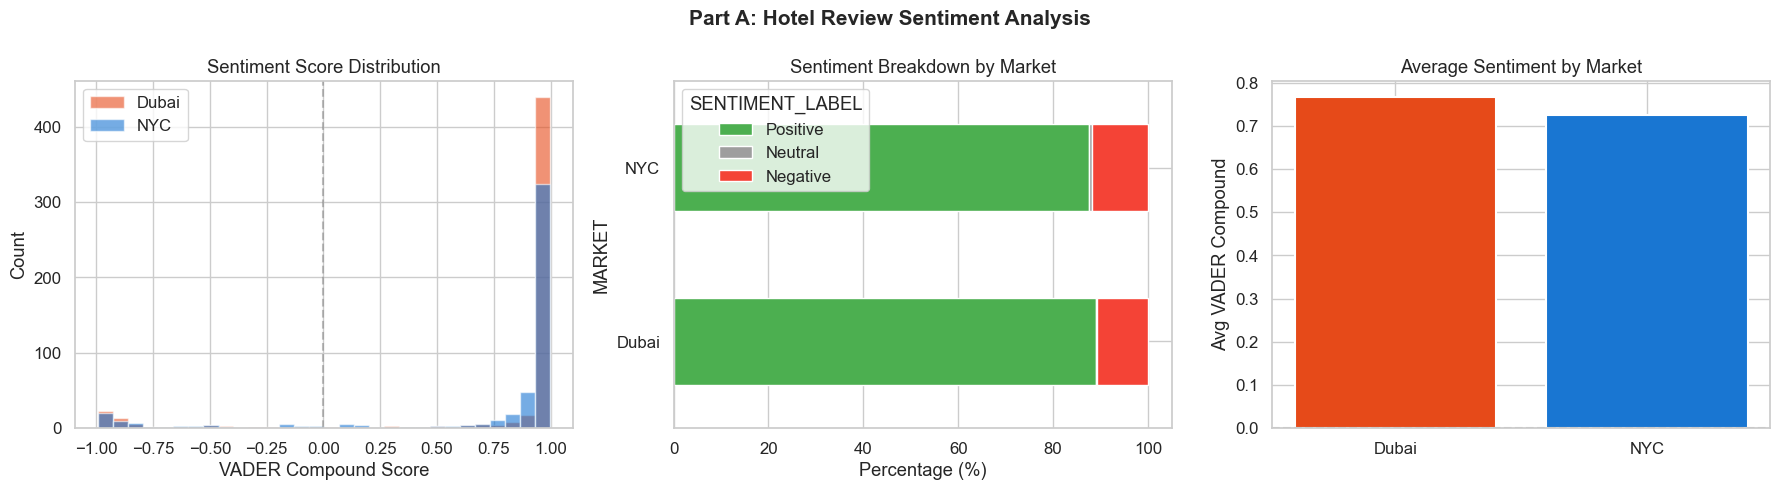

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Compound score distribution
for market, color in [("Dubai", "#e64a19"), ("NYC", "#1976d2")]:
    mask = reviews["MARKET"] == market
    axes[0].hist(
        reviews.loc[mask, "VADER_COMPOUND"], bins=30, alpha=0.6,
        label=market, color=color, edgecolor="white",
    )
axes[0].set_xlabel("VADER Compound Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Sentiment Score Distribution")
axes[0].legend()
axes[0].axvline(0, color="gray", linestyle="--", alpha=0.5)

# 2. Sentiment label breakdown
sentiment_ct = pd.crosstab(
    reviews["MARKET"], reviews["SENTIMENT_LABEL"], normalize="index"
) * 100
sentiment_ct[["Positive", "Neutral", "Negative"]].plot(
    kind="barh", stacked=True, ax=axes[1],
    color=["#4caf50", "#9e9e9e", "#f44336"],
)
axes[1].set_xlabel("Percentage (%)")
axes[1].set_title("Sentiment Breakdown by Market")

# 3. Avg compound by market
market_sent = aggregate_sentiment_by_group(reviews, "MARKET")
axes[2].bar(
    market_sent["MARKET"], market_sent["AVG_COMPOUND"],
    color=["#e64a19", "#1976d2"], edgecolor="white", linewidth=1.5,
)
axes[2].set_ylabel("Avg VADER Compound")
axes[2].set_title("Average Sentiment by Market")
axes[2].axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.suptitle("Part A: Hotel Review Sentiment Analysis",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/m05_sentiment_by_market.png",
            dpi=150, bbox_inches="tight")
plt.show()

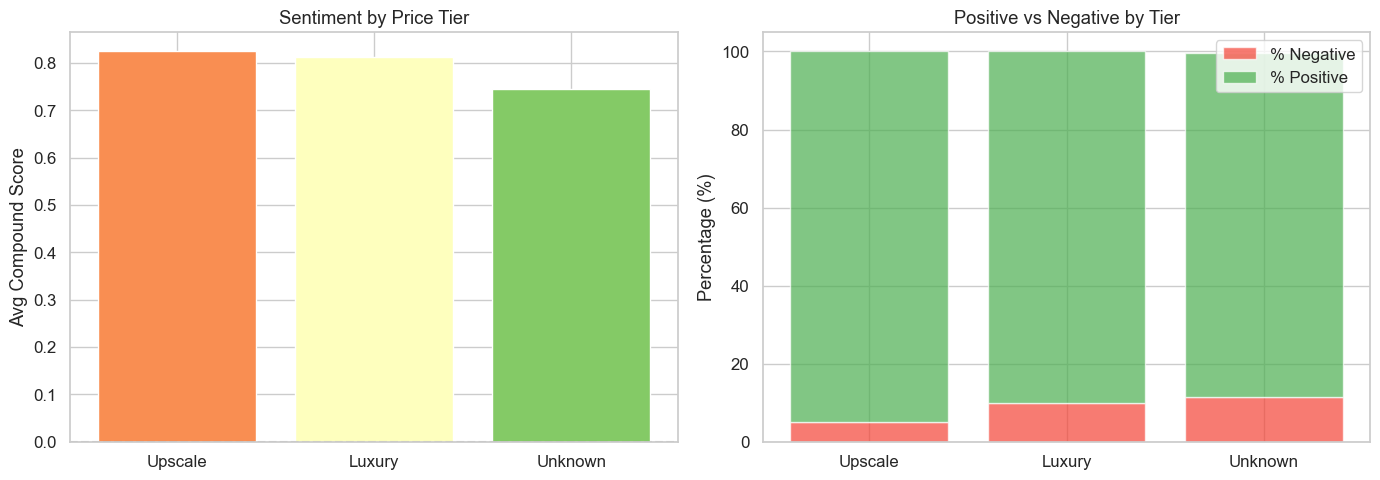

In [6]:
tier_sent = aggregate_sentiment_by_group(reviews, "PRICE_TIER")
tier_order = ["Budget", "Mid-Range", "Upscale", "Luxury", "Unknown"]
tier_sent["PRICE_TIER"] = pd.Categorical(
    tier_sent["PRICE_TIER"], categories=tier_order, ordered=True
)
tier_sent = tier_sent.sort_values("PRICE_TIER")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    tier_sent["PRICE_TIER"], tier_sent["AVG_COMPOUND"],
    color=sns.color_palette("RdYlGn", n_colors=len(tier_sent)),
    edgecolor="white",
)
axes[0].set_ylabel("Avg Compound Score")
axes[0].set_title("Sentiment by Price Tier")
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)

axes[1].bar(
    tier_sent["PRICE_TIER"], tier_sent["PCT_NEGATIVE"],
    color="#f44336", alpha=0.7, label="% Negative",
)
axes[1].bar(
    tier_sent["PRICE_TIER"], tier_sent["PCT_POSITIVE"],
    color="#4caf50", alpha=0.7, label="% Positive", bottom=tier_sent["PCT_NEGATIVE"],
)
axes[1].set_ylabel("Percentage (%)")
axes[1].set_title("Positive vs Negative by Tier")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/figures/m05_sentiment_by_tier.png",
            dpi=150, bbox_inches="tight")
plt.show()

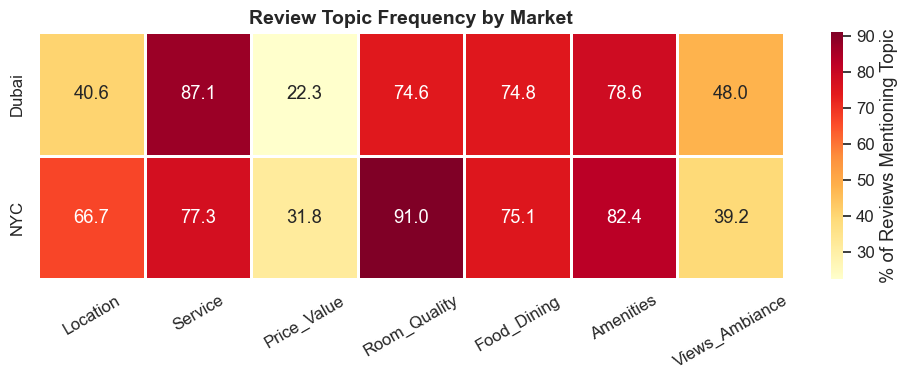

In [7]:
topic_cols = [c for c in reviews.columns if c.startswith("TOPIC_")]
topic_by_market = reviews.groupby("MARKET")[topic_cols].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    topic_by_market, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
    linewidths=1, linecolor="white",
    cbar_kws={"label": "% of Reviews Mentioning Topic"},
)
ax.set_title("Review Topic Frequency by Market", fontsize=14, fontweight="bold")
ax.set_ylabel("")
ax.set_xticklabels([c.replace("TOPIC_", "").title() for c in topic_cols], rotation=30)
plt.tight_layout()
plt.savefig("../outputs/figures/m05_topic_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()


Rating ↔ Sentiment correlation: 0.657
  Mismatched hotels: 10


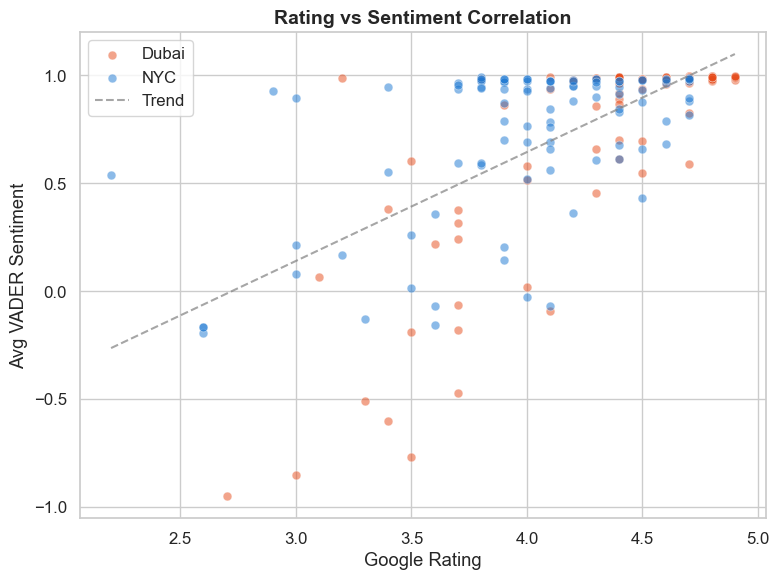

In [8]:
rating_corr = sentiment_rating_correlation(reviews)

fig, ax = plt.subplots(figsize=(8, 6))
for market, color in [("Dubai", "#e64a19"), ("NYC", "#1976d2")]:
    mask = rating_corr["MARKET"] == market
    ax.scatter(
        rating_corr.loc[mask, "GOOGLE_RATING"],
        rating_corr.loc[mask, "AVG_SENTIMENT"],
        alpha=0.5, s=40, color=color, label=market,
        edgecolors="white", linewidths=0.5,
    )

# Trend line
x = rating_corr["GOOGLE_RATING"].dropna()
y = rating_corr.loc[x.index, "AVG_SENTIMENT"]
if len(x) > 2:
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 50)
    ax.plot(x_line, p(x_line), "--", color="gray", alpha=0.7, label="Trend")

ax.set_xlabel("Google Rating")
ax.set_ylabel("Avg VADER Sentiment")
ax.set_title("Rating vs Sentiment Correlation", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/m05_rating_vs_sentiment.png",
            dpi=150, bbox_inches="tight")
plt.show()

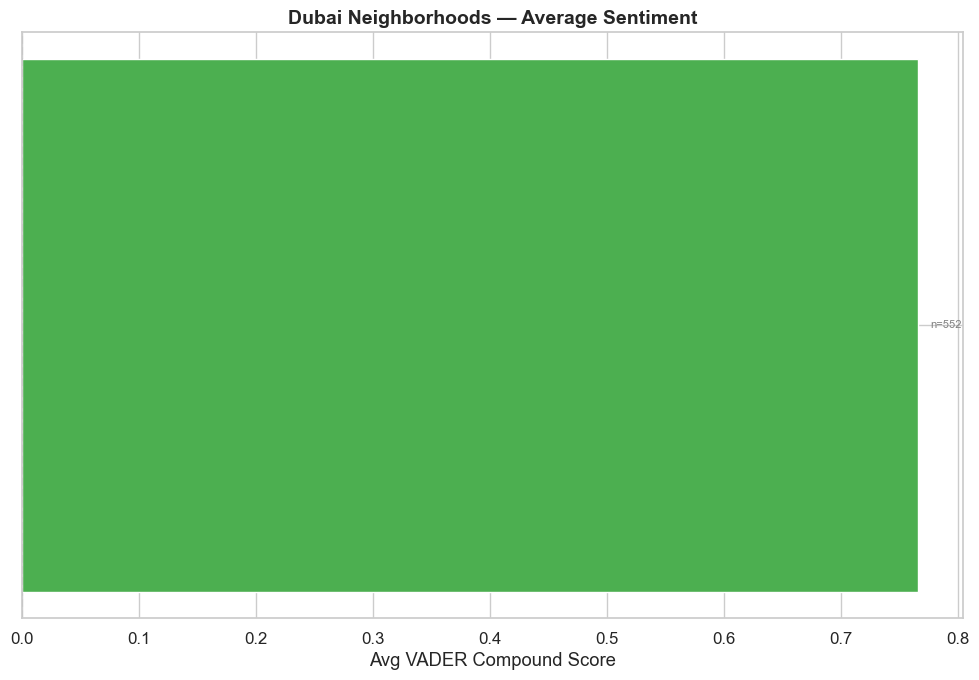

In [9]:
dubai_reviews = reviews[reviews["MARKET"] == "Dubai"]
hood_sent = aggregate_sentiment_by_group(dubai_reviews, "NEIGHBORHOOD")
hood_sent = hood_sent.sort_values("AVG_COMPOUND", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#f44336" if v < 0 else "#4caf50" for v in hood_sent["AVG_COMPOUND"]]
ax.barh(hood_sent["NEIGHBORHOOD"], hood_sent["AVG_COMPOUND"], color=colors, edgecolor="white")
ax.set_xlabel("Avg VADER Compound Score")
ax.set_title("Dubai Neighborhoods — Average Sentiment", fontsize=14, fontweight="bold")
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)

# Annotate review count
for i, (_, row) in enumerate(hood_sent.iterrows()):
    ax.text(
        row["AVG_COMPOUND"] + 0.01 * (1 if row["AVG_COMPOUND"] >= 0 else -1),
        i, f"n={int(row['REVIEW_COUNT'])}",
        va="center", fontsize=8, color="gray",
    )

plt.tight_layout()
plt.savefig("../outputs/figures/m05_dubai_neighborhood_sentiment.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [10]:
yt = prepare_youtube_data(youtube)
yt.head()

Prepared YouTube data: 200 videos
  Total views: 46,700,293
  Avg engagement rate: 4.82%


,VIDEO_ID,TITLE,DESCRIPTION,CHANNEL_TITLE,CHANNEL_ID,CHANNEL_SUBSCRIBERS,CHANNEL_TYPE,PUBLISHED_AT,SEARCH_QUERY,CONTENT_THEME,...,DURATION_MINUTES,DURATION,PUBLISH_YEAR,PUBLISH_MONTH,PUBLISH_DOW,LIKE_RATE,COMMENT_RATE,ENGAGEMENT_RATE,VIEW_TIER,DURATION_BUCKET
0,SYNTH_YT_0000,"Dubai Travel Guide for US Citizens | Visa, Mon...",Join me on my journey from New York to Dubai! ...,Travel Tips by Dheeraj,UCF000000,25000,small,2025-08-05 00:00:00+00:00,Dubai travel guide from New York,travel_guide,...,14,PT14M52S,2025,8,Tuesday,6.706,0.469,7.175,Micro (<10K),Standard (10-20m)
1,SYNTH_YT_0001,Emirates A380 Business Class Review (JFK→DXB),Join me on my journey from New York to Dubai! ...,Sorelle Amore,UCO000001,1100000,lifestyle,2025-08-28 00:00:00+00:00,flying to Dubai from JFK,flight_review,...,23,PT23M41S,2025,8,Thursday,2.430,0.057,2.488,Medium (50-200K),Long (20-30m)
2,SYNTH_YT_0002,Dubai Travel Vlog 2024 | From New York to the ...,Join me on my journey from New York to Dubai! ...,NY to Anywhere,UCE000002,95000,small,2025-02-07 00:00:00+00:00,NYC to Dubai travel vlog,travel_vlog,...,9,PT9M50S,2025,2,Friday,3.794,0.623,4.417,Small (10-50K),Medium (5-10m)
3,SYNTH_YT_0003,Dubai Desert Safari - Is It a Tourist Trap?,In this video I share my experience dubai dese...,Wolters World,UCH000003,1600000,tips,2025-11-14 00:00:00+00:00,Dubai things to do American tourist,things_to_do,...,21,PT21M46S,2025,11,Friday,3.981,0.415,4.396,Medium (50-200K),Long (20-30m)
4,SYNTH_YT_0004,NYC to Dubai FIRST CLASS on Emirates A380!,Join me on my journey from New York to Dubai! ...,Budget Backpacker,UCB000004,420000,budget,2025-10-18 00:00:00+00:00,NYC to Dubai travel vlog,travel_vlog,...,25,PT25M25S,2025,10,Saturday,6.162,1.598,7.761,Small (10-50K),Long (20-30m)


In [11]:
theme_perf = analyze_theme_performance(yt)
display(theme_perf)


Theme Performance:
  travel_vlog: 50 videos, 12,101,414 views, 5.63% engagement
  travel_guide: 33 videos, 11,910,086 views, 4.10% engagement
  flight_review: 20 videos, 8,009,275 views, 4.44% engagement
  things_to_do: 35 videos, 6,897,565 views, 5.51% engagement
  hotel_review: 46 videos, 6,159,724 views, 4.43% engagement
  budget_planning: 16 videos, 1,622,229 views, 3.86% engagement


,CONTENT_THEME,VIDEO_COUNT,TOTAL_VIEWS,AVG_VIEWS,MEDIAN_VIEWS,AVG_LIKES,AVG_COMMENTS,AVG_LIKE_RATE,AVG_COMMENT_RATE,AVG_ENGAGEMENT,VIEW_SHARE_PCT
5,travel_vlog,50,12101414,242028.28,107646.0,12130.08,1618.90,4.92,0.71,5.63,25.9
4,travel_guide,33,11910086,360911.70,211464.0,12044.21,1718.45,3.63,0.47,4.10,25.5
1,flight_review,20,8009275,400463.75,247844.0,15962.50,2171.30,3.83,0.61,4.44,17.2
3,things_to_do,35,6897565,197073.29,139603.0,9903.20,1259.86,4.87,0.65,5.51,14.8
2,hotel_review,46,6159724,133907.04,40041.0,4445.43,742.28,3.88,0.54,4.43,13.2
0,budget_planning,16,1622229,101389.31,26062.0,2189.88,694.44,3.37,0.50,3.86,3.5


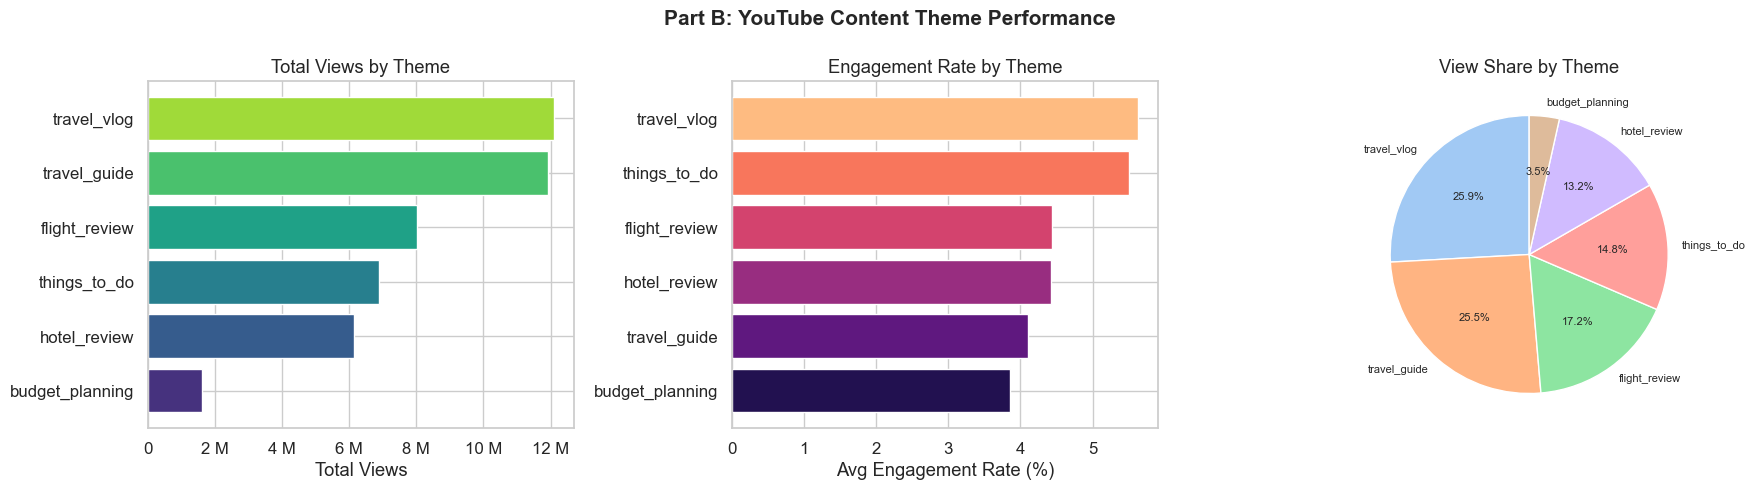

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Total views by theme
theme_perf_sorted = theme_perf.sort_values("TOTAL_VIEWS", ascending=True)
axes[0].barh(
    theme_perf_sorted["CONTENT_THEME"],
    theme_perf_sorted["TOTAL_VIEWS"],
    color=sns.color_palette("viridis", n_colors=len(theme_perf)),
    edgecolor="white",
)
axes[0].set_xlabel("Total Views")
axes[0].set_title("Total Views by Theme")
axes[0].xaxis.set_major_formatter(mtick.EngFormatter())

# 2. Avg engagement rate
theme_eng = theme_perf.sort_values("AVG_ENGAGEMENT", ascending=True)
axes[1].barh(
    theme_eng["CONTENT_THEME"],
    theme_eng["AVG_ENGAGEMENT"],
    color=sns.color_palette("magma", n_colors=len(theme_perf)),
    edgecolor="white",
)
axes[1].set_xlabel("Avg Engagement Rate (%)")
axes[1].set_title("Engagement Rate by Theme")

# 3. View share pie
theme_perf.set_index("CONTENT_THEME")["VIEW_SHARE_PCT"].plot(
    kind="pie", ax=axes[2], autopct="%1.1f%%",
    startangle=90, textprops={"fontsize": 8},
    colors=sns.color_palette("pastel", n_colors=len(theme_perf)),
)
axes[2].set_ylabel("")
axes[2].set_title("View Share by Theme")

plt.suptitle("Part B: YouTube Content Theme Performance",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/m05_theme_performance.png",
            dpi=150, bbox_inches="tight")
plt.show()